**MNIST Denoising Autoencoder**

*Objective*
The objective of this project is to build a Denoising Autoencoder using the MNIST handwritten digit dataset. The model is trained on noisy images and learns to reconstruct the corresponding clean images.

1.) Load and preprocess the MNIST Dataset

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
train_path = r"C:\Users\HP\Downloads\archive(4)\mnist_png\training"

test_path = r"C:\Users\HP\Downloads\archive(4)\mnist_png\testing"

Load Images Function

In [3]:
def load_images(folder_path):

    images = []
    labels = []

    for label in sorted(os.listdir(folder_path)):

        label_folder = os.path.join(folder_path, label)

        if os.path.isdir(label_folder):

            for filename in os.listdir(label_folder):

                image_path = os.path.join(label_folder, filename)

                image = Image.open(image_path).convert("L")

                image = image.resize((28,28))

                image = np.array(image)

                images.append(image)

                labels.append(int(label))

    return np.array(images), np.array(labels)

Load Training Dataset

In [4]:
X_train, y_train = load_images(train_path)

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)


PreProcess Training data

In [6]:
X_train = X_train.astype("float32") / 255.0

X_train = X_train.reshape(-1,784)

print(X_train.shape)

(60000, 784)


2.) Adding Artificial Noise to create noisy input images

*Display Sample Training Images*

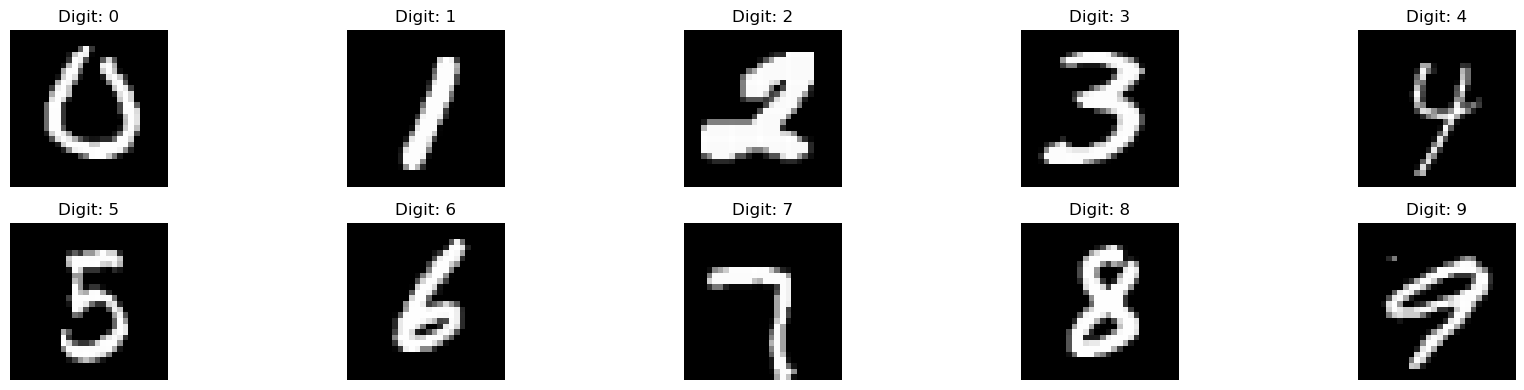

In [7]:
plt.figure(figsize=(18, 4))

for digit in range(10):

    # Get indices of all images belonging to the current digit
    indices = np.where(y_train == digit)[0]

    # Randomly select one image
    idx = random.choice(indices)

    plt.subplot(2, 5, digit + 1)
    plt.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Digit: {digit}")
    plt.axis('off')

plt.tight_layout()
plt.show()

*Adding Gaussian Noise to Training Images*

In [8]:
noise_factor = 0.5

X_train_noisy = X_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_train.shape
)

# Keep pixel values between 0 and 1
X_train_noisy = np.clip(X_train_noisy, 0., 1.)

*Comparison of Original to Noisy data*

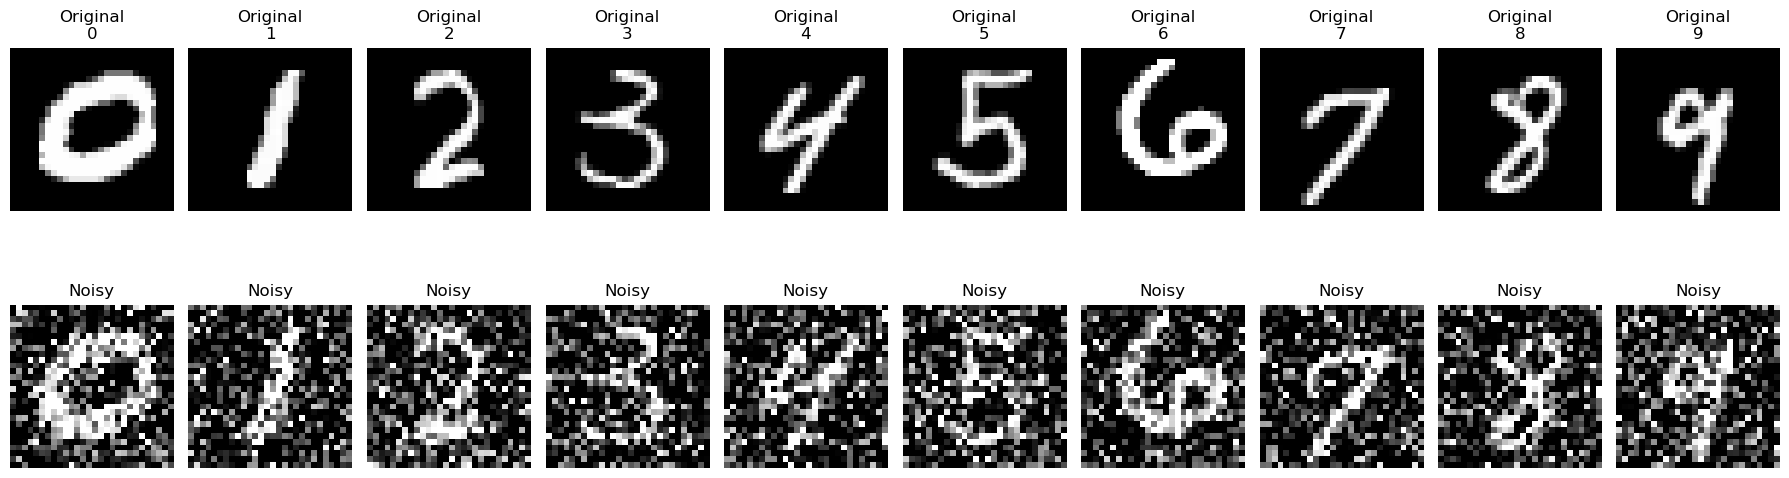

In [9]:
plt.figure(figsize=(18, 6))

for digit in range(10):

    indices = np.where(y_train == digit)[0]
    idx = random.choice(indices)

    # Original Image
    plt.subplot(2, 10, digit + 1)
    plt.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Original\n{digit}")
    plt.axis('off')

    # Noisy Image
    plt.subplot(2, 10, digit + 11)
    plt.imshow(X_train_noisy[idx].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.tight_layout()
plt.show()

3.) Building and Training a Denoising Autoencoder where using the Noised image as an input and clean Images as target

*Build the Denoising Autoencoder*

In [10]:
# Input Layer
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

# Autoencoder Model
autoencoder = Model(inputs=input_img, outputs=decoded)

*Model Summary*

In [11]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 784)                 │         101,136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

*Compiling the Model*

In [12]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

Loading Testing Dataset

In [13]:
X_test, y_test = load_images(test_path)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


*PreProcessing testing Dataset*

In [14]:
X_test = X_test.astype("float32") / 255.0

X_test = X_test.reshape(-1, 784)

print(X_test.shape)

(10000, 784)


*Add Noise to Testing Dataset*

In [15]:
noise_factor = 0.5

X_test_noisy = X_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_test.shape
)

X_test_noisy = np.clip(X_test_noisy, 0., 1.)

*Verify The Shapes*

In [16]:
print("X_train:", X_train.shape)
print("X_train_noisy:", X_train_noisy.shape)

print("X_test:", X_test.shape)
print("X_test_noisy:", X_test_noisy.shape)

X_train: (60000, 784)
X_train_noisy: (60000, 784)
X_test: (10000, 784)
X_test_noisy: (10000, 784)


*Training The Autoencoders*

In [18]:
history = autoencoder.fit(
    X_train_noisy,
    X_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_noisy, X_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2524 - val_loss: 0.1840
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1679 - val_loss: 0.1550
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1487 - val_loss: 0.1422
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1392 - val_loss: 0.1344
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1328 - val_loss: 0.1299
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1290 - val_loss: 0.1267
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1265 - val_loss: 0.1250
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1245 - val_loss: 0.1230
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1228 - val_loss: 0.1223
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1215 - val_loss: 0.1208
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1203 - val_loss: 0.1200
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s

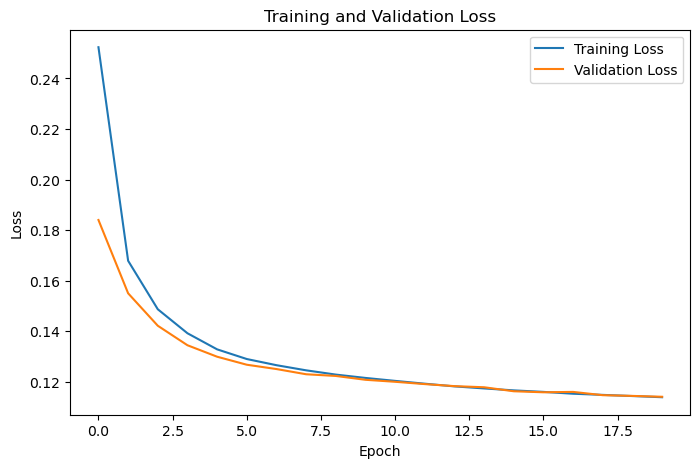

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

4.) Generate Denoised Outputs on the Test Set

*Generate Denoised Images*

In [20]:
denoised_images = autoencoder.predict(X_test_noisy)

print("Denoised Images Shape:", denoised_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  
Denoised Images Shape: (10000, 784)


*MSE---> Mean Square Error*

In [21]:
mse = np.mean((X_test - denoised_images) ** 2)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.016824793


*Plot Training and Validation Loss*(also mentioned above under task 3)

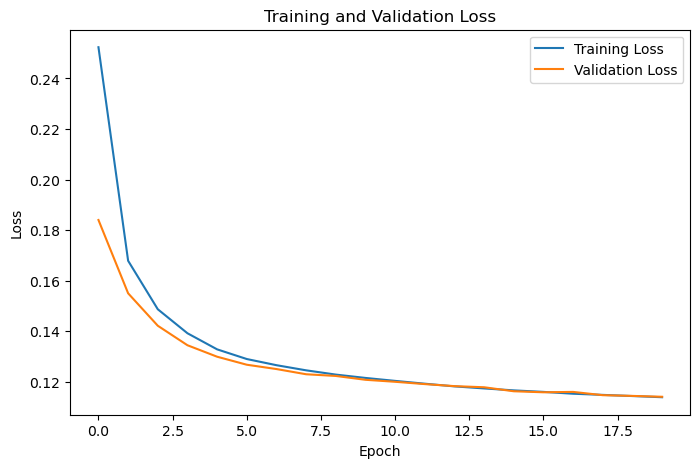

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

*Display Original, Noisy and Denoised Images*

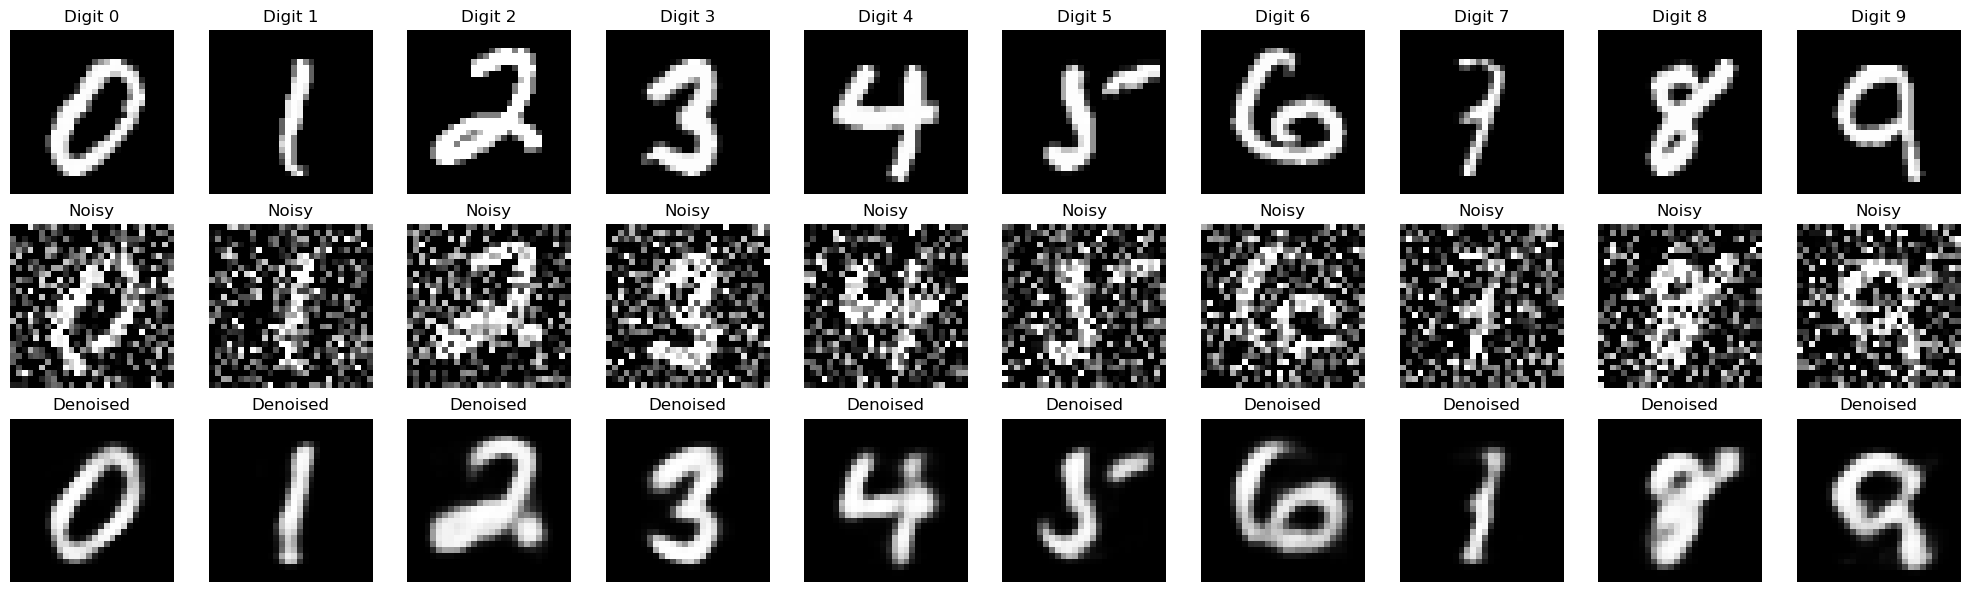

In [24]:
import random

selected_indices = []

# Select one random image for each digit
for digit in range(10):

    indices = np.where(y_test == digit)[0]
    idx = random.choice(indices)

    selected_indices.append(idx)

plt.figure(figsize=(20,6))

for i, idx in enumerate(selected_indices):

    # Original Image
    plt.subplot(3,10,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Digit {y_test[idx]}")
    plt.axis('off')

    # Noisy Image
    plt.subplot(3,10,i+11)
    plt.imshow(X_test_noisy[idx].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised Image
    plt.subplot(3,10,i+21)
    plt.imshow(denoised_images[idx].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

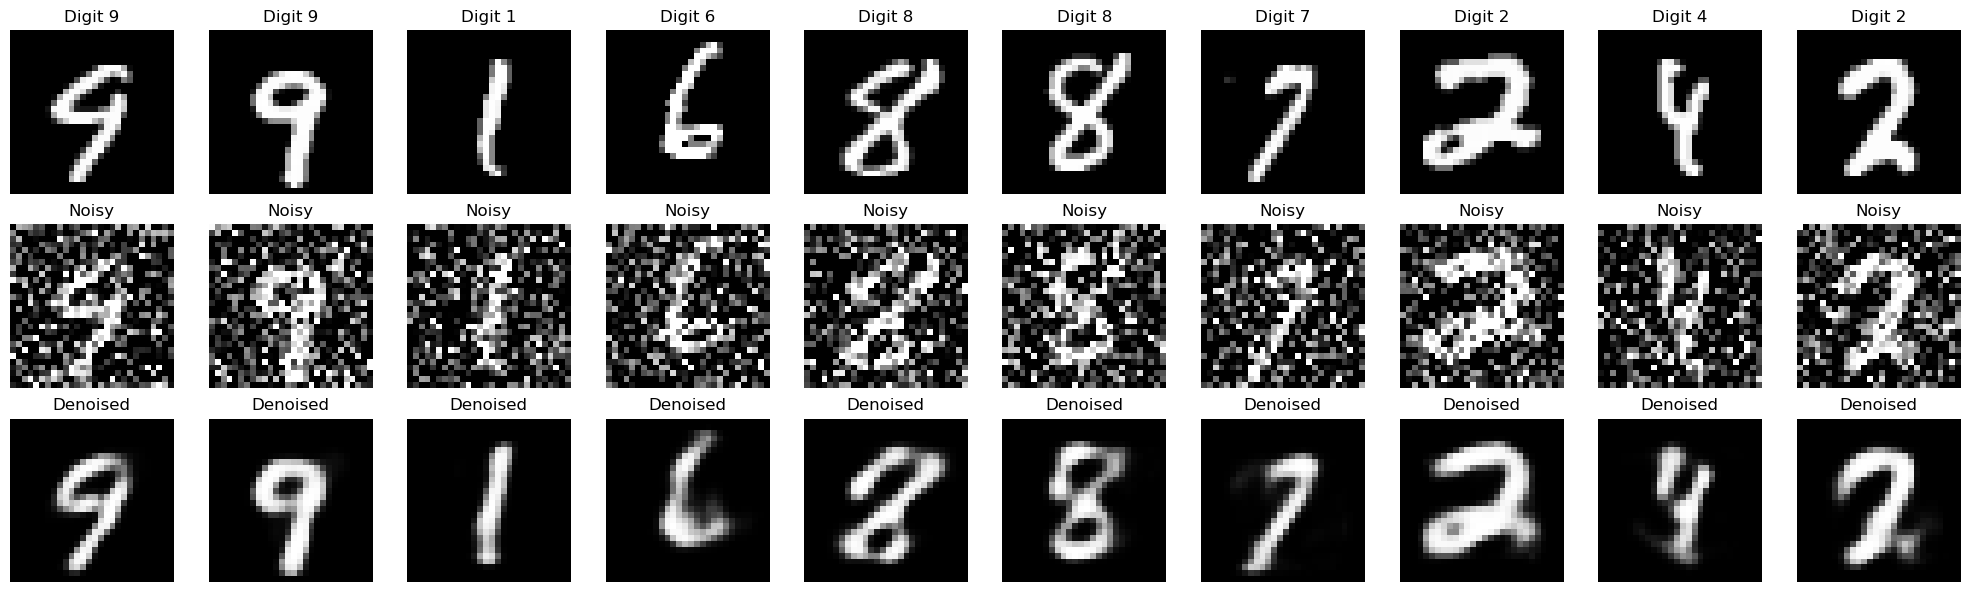

In [25]:
n = 10

# Randomly select 10 images from the test dataset
random_indices = random.sample(range(len(X_test)), n)

plt.figure(figsize=(20,6))

for i, idx in enumerate(random_indices):

    # Original Image
    plt.subplot(3, n, i + 1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Digit {y_test[idx]}")
    plt.axis('off')

    # Noisy Image
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[idx].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised Image
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_images[idx].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

Display Model Performance

In [26]:
print("="*40)
print("Model Performance")
print("="*40)

print(f"Training Loss   : {history.history['loss'][-1]:.4f}")
print(f"Validation Loss : {history.history['val_loss'][-1]:.4f}")
print(f"Test MSE        : {mse:.6f}")

Model Performance
Training Loss   : 0.1139
Validation Loss : 0.1140
Test MSE        : 0.016825
